# Imports


In [4]:
import numpy as np
import pandas as pd
import os
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from scipy.linalg import orthogonal_procrustes
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

from paths import (
    vision_emb_path, text_emb_path,
    projection_dir, projection_matrix_path,
    projected_emb_path, fusion_query_path,
    projection_metrics_path
)

CURRENT_DATASET = "Flickr8k"
LATENT_DIM = 128

vision_models = {
    "ResNet50": np.load(vision_emb_path(CURRENT_DATASET, "ResNet50")),
    "ViT":      np.load(vision_emb_path(CURRENT_DATASET, "ViT")),
    "MobileNetV3": np.load(vision_emb_path(CURRENT_DATASET, "MobileNetV3")),
    "PVT": np.load(vision_emb_path(CURRENT_DATASET, "PVT")),
}

text_raw = {
    "BERT":    np.load(text_emb_path(CURRENT_DATASET, "BERT")),
    "RoBERTa": np.load(text_emb_path(CURRENT_DATASET, "RoBERTa")),
    "GPT-2":   np.load(text_emb_path(CURRENT_DATASET, "GPT2")),
}

def group_captions(Xt_raw, k=5):
    N = Xt_raw.shape[0] // k
    return Xt_raw.reshape(N, k, -1).mean(axis=1)

text_models = {k: group_captions(v) for k, v in text_raw.items()}


/home/aysel/tfe/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


# Projection

In [6]:
def proj_random(Dv, Dt, dim):
    return np.random.randn(Dv, dim), np.random.randn(Dt, dim)

def cluster_aware_pca(Xv, Xt_raw, dim=128):
    N = Xv.shape[0]

    pca_v = PCA(dim).fit(Xv)
    pca_t = PCA(dim).fit(Xt_raw)

    Xv_pca = pca_v.transform(Xv)
    Xt_pca = pca_t.transform(Xt_raw)

    Xt_grouped = Xt_pca.reshape(N, 5, dim)
    centroids_t = Xt_grouped.mean(axis=1)
    centroids_v = Xv_pca

    R, _ = orthogonal_procrustes(centroids_t, centroids_v)

    Wv = pca_v.components_.T
    Wt = pca_t.components_.T @ R

    return Wv, Wt

def weighted_cca(Xv, Xt, dim=128, alpha=0.1):
    N = Xv.shape[0]

    C_xy_pos = Xv.T @ Xt
    C_xy_neg = Xv.T @ Xt[np.random.permutation(N)]

    C_xy = C_xy_pos + alpha * C_xy_neg

    U, S, Vt = np.linalg.svd(C_xy, full_matrices=False)

    return U[:, :dim], Vt.T[:, :dim]


In [7]:
results = []

for v_name, Xv in vision_models.items():
    for t_name, Xt in text_models.items():

        Xt_raw = text_raw[t_name]
        Xv_pairs = np.repeat(Xv, 5, axis=0)
        Xt_pairs = Xt_raw

        projection_methods = {
            "RP":    proj_random(Xv.shape[1], Xt_raw.shape[1], LATENT_DIM),
            "WCCA":  weighted_cca(Xv_pairs, Xt_pairs, LATENT_DIM),
            "CPCA":  cluster_aware_pca(Xv, Xt_raw, LATENT_DIM)
        }

        for method, (Wv, Wt) in projection_methods.items():

            out_dir = projection_dir(CURRENT_DATASET, v_name, t_name, method)
            os.makedirs(out_dir, exist_ok=True)

            np.save(projection_matrix_path(CURRENT_DATASET, v_name, t_name, method, "Wv"), Wv)
            np.save(projection_matrix_path(CURRENT_DATASET, v_name, t_name, method, "Wt"), Wt)

            Xv_proj = Xv @ Wv
            Xt_proj = Xt_raw @ Wt

            np.save(projected_emb_path(CURRENT_DATASET, v_name, t_name, method, "Xv"), Xv_proj)
            np.save(projected_emb_path(CURRENT_DATASET, v_name, t_name, method, "Xt"), Xt_proj)

            sims = cosine_similarity(Xv_proj, Xt_proj)
            diag = np.diag(sims)

            results.append({
                "vision": v_name,
                "text": t_name,
                "method": method,
                "alignment_mean": diag.mean(),
                "alignment_std": diag.std()
            })


In [8]:
df = pd.DataFrame(results)
out_path = projection_metrics_path(CURRENT_DATASET)
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df.to_csv(out_path, index=False)
df


,vision,text,method,alignment_mean,alignment_std
0,ResNet50,BERT,RP,0.043763,0.086014
1,ResNet50,BERT,WCCA,0.468530,0.106479
2,ResNet50,BERT,CPCA,0.103862,0.112836
3,ResNet50,RoBERTa,RP,0.037008,0.083310
4,ResNet50,RoBERTa,WCCA,0.530103,0.103410
5,ResNet50,RoBERTa,CPCA,0.099853,0.087427
6,ResNet50,GPT-2,RP,0.058472,0.074005
7,ResNet50,GPT-2,WCCA,0.535276,0.105005
8,ResNet50,GPT-2,CPCA,0.142618,0.136177
9,ViT,BERT,RP,-0.015621,0.084400


# Fusion

In [9]:
fusion_ops = {
    "add": lambda Xv, Xt: Xv + Xt,
    "gated": lambda Xv, Xt: 0.5 * Xv + 0.5 * Xt,
    "mul": lambda Xv, Xt: Xv * Xt
}

for v_name, Xv in vision_models.items():
    for t_name, Xt_raw in text_raw.items():

        for method in ["RP", "WCCA", "CPCA"]:

            Wv = np.load(projection_matrix_path(CURRENT_DATASET, v_name, t_name, method, "Wv"))
            Wt = np.load(projection_matrix_path(CURRENT_DATASET, v_name, t_name, method, "Wt"))

            Xv_proj = Xv @ Wv
            Xt_proj = Xt_raw @ Wt

            Xv_rep = np.repeat(Xv_proj, 5, axis=0)

            for op_name, op in fusion_ops.items():
                F = op(Xv_rep, Xt_proj)
                np.save(fusion_query_path(CURRENT_DATASET, v_name, t_name, method, op_name), F)


# Alignment and Cluster Analysis

In [10]:
def compute_alignment(Xv_proj, Xt_proj):
    sims = cosine_similarity(Xv_proj, Xt_proj)
    diag = np.diag(sims)
    return {
        "alignment_mean": diag.mean(),
        "alignment_std": diag.std(),
        "alignment_diag": diag
    }


In [11]:
def compute_cluster_metrics(Xv_proj, Xt_proj):
    N, D = Xv_proj.shape

    Xt_grouped = Xt_proj.reshape(N, 5, D)

    # Intra-cluster distances
    intra = np.linalg.norm(Xv_proj[:, None, :] - Xt_grouped, axis=2).mean()

    # Inter-cluster distances (sampled)
    inter_samples = 20
    inter_vals = []

    for i in range(N):
        neg_idx = np.random.choice([k for k in range(N) if k != i], inter_samples, replace=False)
        j = np.random.randint(0, 5, size=inter_samples)
        inter_vals.extend(np.linalg.norm(Xv_proj[i] - Xt_grouped[neg_idx, j], axis=1))

    inter = np.mean(inter_vals)

    # Silhouette score
    X_all = np.vstack([Xv_proj, Xt_proj])
    labels = np.repeat(np.arange(N), 6)
    sil = silhouette_score(X_all, labels)

    return {
        "intra_cluster": intra,
        "inter_cluster": inter,
        "silhouette": sil
    }


In [12]:
from paths import (
    projection_dir, projection_matrix_path,
    projected_emb_path, projection_metrics_path
)

def evaluate_all_projections(dataset, vision_models, text_models, methods=["RP","WCCA","CPCA"]):
    results = []

    for v_name in vision_models:
        for t_name in text_models:

            for method in methods:

                # Load projected embeddings
                Xv_proj = np.load(projected_emb_path(dataset, v_name, t_name, method, "Xv"))
                Xt_proj = np.load(projected_emb_path(dataset, v_name, t_name, method, "Xt"))

                # Alignment
                align = compute_alignment(Xv_proj, Xt_proj)

                # Cluster metrics
                cluster = compute_cluster_metrics(Xv_proj, Xt_proj)

                results.append({
                    "dataset": dataset,
                    "vision": v_name,
                    "text": t_name,
                    "method": method,
                    "alignment_mean": align["alignment_mean"],
                    "alignment_std": align["alignment_std"],
                    "intra_cluster": cluster["intra_cluster"],
                    "inter_cluster": cluster["inter_cluster"],
                    "silhouette": cluster["silhouette"]
                })

    df = pd.DataFrame(results)

    out_path = projection_metrics_path(dataset)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    df.to_csv(out_path, index=False)

    return df


In [13]:
df_proj = evaluate_all_projections(CURRENT_DATASET, vision_models, text_models)
df_proj


,dataset,vision,text,method,alignment_mean,alignment_std,intra_cluster,inter_cluster,silhouette
0,Flickr8k,ResNet50,BERT,RP,0.043763,0.086014,199.462548,199.328732,-0.159214
1,Flickr8k,ResNet50,BERT,WCCA,0.468530,0.106479,9.737306,11.452937,-0.186709
2,Flickr8k,ResNet50,BERT,CPCA,0.103862,0.112836,12.853056,14.117075,-0.165214
3,Flickr8k,ResNet50,RoBERTa,RP,0.037008,0.083310,201.243179,201.185515,-0.153068
4,Flickr8k,ResNet50,RoBERTa,WCCA,0.530103,0.103410,10.943357,11.557700,-0.175328
5,Flickr8k,ResNet50,RoBERTa,CPCA,0.099853,0.087427,15.249833,15.670288,-0.160901
6,Flickr8k,ResNet50,GPT-2,RP,0.058472,0.074005,2334.393350,2335.046610,-0.362946
7,Flickr8k,ResNet50,GPT-2,WCCA,0.535276,0.105005,203.527420,203.687973,-0.374588
8,Flickr8k,ResNet50,GPT-2,CPCA,0.142618,0.136177,208.308960,208.418167,-0.370936
9,Flickr8k,ViT,BERT,RP,-0.015621,0.084400,132.563739,132.396756,-0.152610


In [20]:
df_proj.to_csv(projection_metrics_path(CURRENT_DATASET), index=False)


In [4]:
import pandas as pd

df = pd.read_csv(
    "TFE_Data/TFE_Data/Model_Artifacts/projections/Flickr8k/projection_metrics.csv"
)

allowed = ["MobileNetV3", "ResNet50", "GPT-2", "RoBERTa"]

df_filtered = df[
    df["vision"].isin(allowed) &
    df["text"].isin(allowed)
]
df_filtered.drop(columns= ["dataset", "intra_cluster", "inter_cluster", "silhouette"])

,vision,text,method,alignment_mean,alignment_std
3,ResNet50,RoBERTa,RP,0.037008,0.083310
4,ResNet50,RoBERTa,WCCA,0.530103,0.103410
5,ResNet50,RoBERTa,CPCA,0.099853,0.087427
6,ResNet50,GPT-2,RP,0.058472,0.074005
7,ResNet50,GPT-2,WCCA,0.535276,0.105005
8,ResNet50,GPT-2,CPCA,0.142618,0.136177
21,MobileNetV3,RoBERTa,RP,-0.067810,0.082452
22,MobileNetV3,RoBERTa,WCCA,0.559833,0.128592
23,MobileNetV3,RoBERTa,CPCA,0.130463,0.086136
24,MobileNetV3,GPT-2,RP,-0.003448,0.075071


In [19]:
df = pd.read_csv(
    "TFE_Data/TFE_Data/Model_Artifacts/projections/Flickr8k/projection_metrics.csv"
)

#df = df[df["method"] != "RP"]

df.drop(columns= ["dataset", "intra_cluster", "inter_cluster", "silhouette"])

,vision,text,method,alignment_mean,alignment_std
0,ResNet50,BERT,RP,0.043763,0.086014
1,ResNet50,BERT,WCCA,0.468530,0.106479
2,ResNet50,BERT,CPCA,0.103862,0.112836
3,ResNet50,RoBERTa,RP,0.037008,0.083310
4,ResNet50,RoBERTa,WCCA,0.530103,0.103410
5,ResNet50,RoBERTa,CPCA,0.099853,0.087427
6,ResNet50,GPT-2,RP,0.058472,0.074005
7,ResNet50,GPT-2,WCCA,0.535276,0.105005
8,ResNet50,GPT-2,CPCA,0.142618,0.136177
9,ViT,BERT,RP,-0.015621,0.084400


In [20]:
df.sort_values(by = ["alignment_mean"], ascending = False)

,dataset,vision,text,method,alignment_mean,alignment_std,intra_cluster,inter_cluster,silhouette
25,Flickr8k,MobileNetV3,GPT-2,WCCA,0.565542,0.130071,202.479279,202.628189,-0.371958
22,Flickr8k,MobileNetV3,RoBERTa,WCCA,0.559833,0.128592,10.952311,11.574051,-0.177792
7,Flickr8k,ResNet50,GPT-2,WCCA,0.535276,0.105005,203.527420,203.673508,-0.374588
4,Flickr8k,ResNet50,RoBERTa,WCCA,0.530103,0.103410,10.943357,11.557447,-0.175328
19,Flickr8k,MobileNetV3,BERT,WCCA,0.494693,0.125752,10.096828,11.785952,-0.188699
1,Flickr8k,ResNet50,BERT,WCCA,0.468530,0.106479,9.737306,11.451927,-0.186709
16,Flickr8k,ViT,GPT-2,WCCA,0.308675,0.081423,208.779434,208.848724,-0.366437
13,Flickr8k,ViT,RoBERTa,WCCA,0.305886,0.082964,10.960890,11.173626,-0.157583
10,Flickr8k,ViT,BERT,WCCA,0.270580,0.093588,8.873703,9.538854,-0.159747
34,Flickr8k,PVT,GPT-2,WCCA,0.259179,0.105511,205.794937,205.963425,-0.363485


In [22]:
df.groupby("method")[["alignment_mean", "alignment_std"]] \
  .mean() \
  .sort_values(by="alignment_mean", ascending=False)

,alignment_mean,alignment_std
method,,
WCCA,0.398471,0.106449
CPCA,0.080152,0.113243
RP,0.003696,0.082975


In [21]:
df.sort_values(by = ["alignment_mean"])

,dataset,vision,text,method,alignment_mean,alignment_std,intra_cluster,inter_cluster,silhouette
21,Flickr8k,MobileNetV3,RoBERTa,RP,-0.067810,0.082452,226.254756,226.178073,-0.156302
18,Flickr8k,MobileNetV3,BERT,RP,-0.065349,0.076824,211.877944,211.664150,-0.158514
15,Flickr8k,ViT,GPT-2,RP,-0.024631,0.081890,2207.997648,2208.243768,-0.347660
9,Flickr8k,ViT,BERT,RP,-0.015621,0.084400,132.563739,132.341562,-0.152610
24,Flickr8k,MobileNetV3,GPT-2,RP,-0.003448,0.075071,2612.227909,2612.461205,-0.371659
12,Flickr8k,ViT,RoBERTa,RP,-0.000670,0.083885,139.003392,138.996829,-0.150197
14,Flickr8k,ViT,RoBERTa,CPCA,0.010349,0.091649,11.392159,11.577924,-0.151682
30,Flickr8k,PVT,RoBERTa,RP,0.013437,0.084506,273.711736,273.801316,-0.158557
27,Flickr8k,PVT,BERT,RP,0.026979,0.091678,269.416484,269.470027,-0.166680
32,Flickr8k,PVT,RoBERTa,CPCA,0.032602,0.090524,20.409580,20.868790,-0.157584


# Plot

In [14]:
def plot_alignment_by_vision(df):
    plt.figure(figsize=(12,6))
    sns.barplot(data=df, x="vision", y="alignment_mean", hue="method")
    plt.title("Alignment Score by Vision Model")
    plt.ylabel("Mean Diagonal Similarity")
    plt.xlabel("Vision Model")
    plt.axhline(0, color="black", linewidth=1)
    plt.show()


In [15]:
def plot_alignment_by_text(df):
    plt.figure(figsize=(12,6))
    sns.barplot(data=df, x="text", y="alignment_mean", hue="method")
    plt.title("Alignment Score by Text Model")
    plt.ylabel("Mean Diagonal Similarity")
    plt.xlabel("Text Model")
    plt.axhline(0, color="black", linewidth=1)
    plt.show()


In [16]:
def plot_cluster_metrics(df):
    fig, axes = plt.subplots(1, 3, figsize=(18,6))

    sns.barplot(data=df, x="method", y="intra_cluster", ax=axes[0])
    axes[0].set_title("Intra-Cluster Distance")

    sns.barplot(data=df, x="method", y="inter_cluster", ax=axes[1])
    axes[1].set_title("Inter-Cluster Distance")

    sns.barplot(data=df, x="method", y="silhouette", ax=axes[2])
    axes[2].set_title("Silhouette Score")

    plt.tight_layout()
    plt.show()


In [ ]:
df_proj = evaluate_all_projections(CURRENT_DATASET, vision_models, text_models)

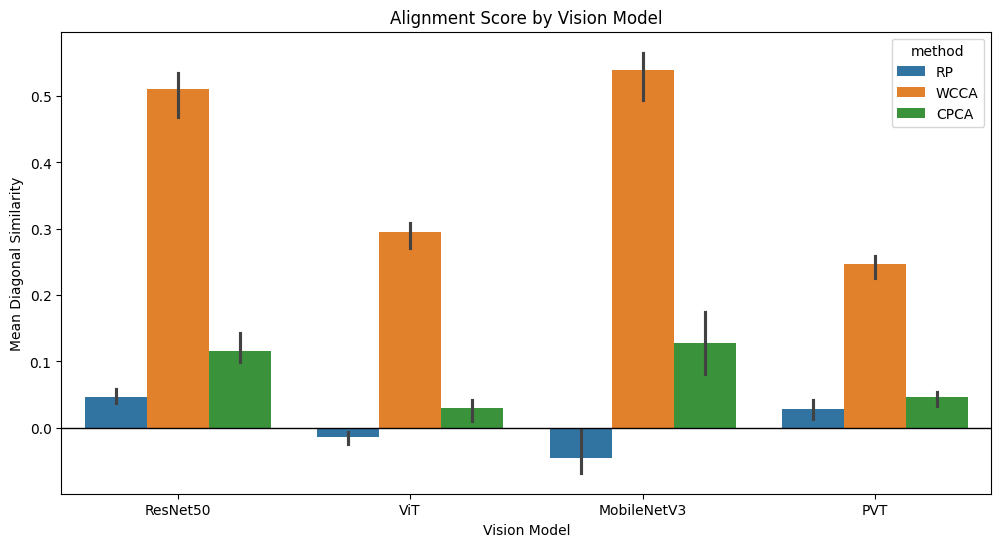

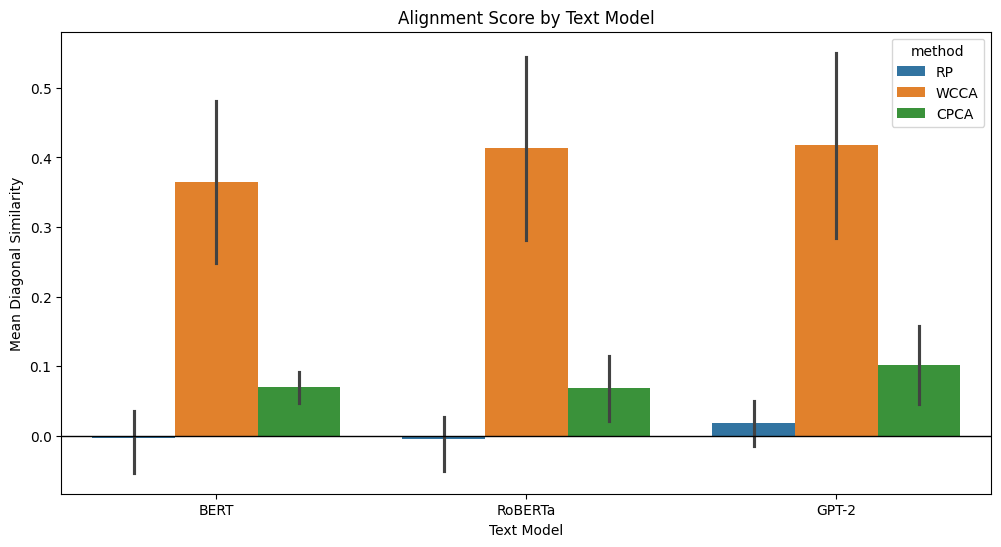

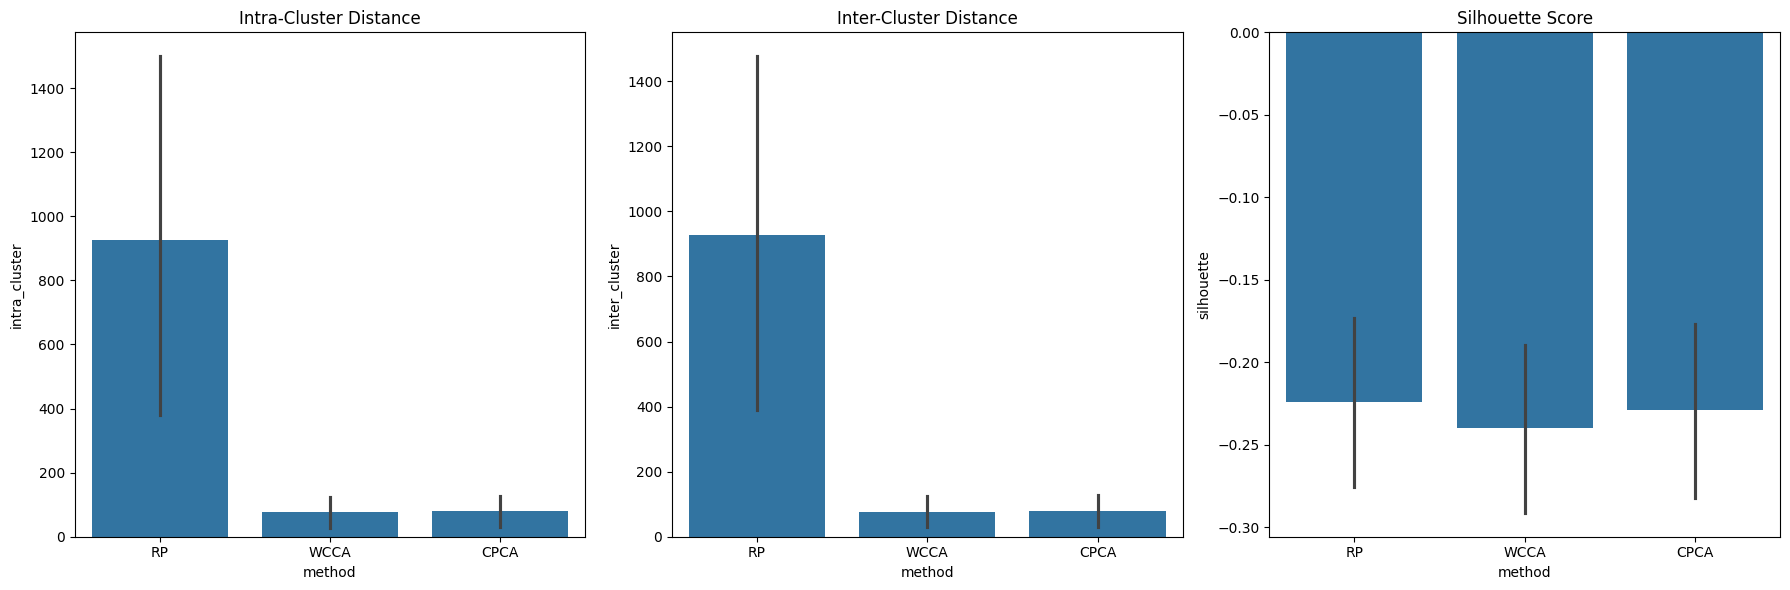

In [ ]:
plot_alignment_by_vision(df_proj)
plot_alignment_by_text(df_proj)
plot_cluster_metrics(df_proj)

In [10]:
TFE_DATA = "/home/aysel/tfe/TFE_Data/TFE_Data/Model_Artifacts/projections/Flickr8k"
def real_projection_paths(dataset, vision, text, method):
    base = os.path.join(TFE_DATA, f"{vision}_{text}", method.upper())
    Wv = os.path.join(base, "Wv.npy")
    Wt = os.path.join(base, "Wt.npy")
    return Wv, Wt
df = pd.read_csv(f"{TFE_DATA}/projection_metrics.csv")

rows = []

for _, row in df.iterrows():
    vision = row["vision"]
    text = row["text"]
    method = row["method"]

    Wv_path, Wt_path = real_projection_paths("Flickr8k", vision, text, method)

    rows.append({
        "vision_model": vision,
        "text_model": text,
        "projection": method.lower(),
        "alignment_mean": row["alignment_mean"],
        "alignment_std": row["alignment_std"],
        "intra_cluster": row["intra_cluster"],
        "inter_cluster": row["inter_cluster"],
        "silhouette": row["silhouette"],
        "Wv_path": Wv_path,
        "Wt_path": Wt_path
    })

meta = pd.DataFrame(rows)
meta.to_csv(f"{TFE_DATA}/fusion_index_metadata.csv", index=False)
